## Basic Chat Chatbot

In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

## persistance memory
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")

In [9]:
def chat_node(state: ChatState):
    
    # take user query from state
    messages = state["messages"]
    
    # send it to LLM
    response = llm.invoke(messages)
    
    ## response stored in state
    return {"messages": [response]}

In [17]:
## memoery checkpointer
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

## add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

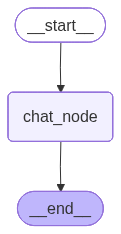

In [11]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [12]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of nepal')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of Nepal is **Kathmandu**.'

In [ ]:
while True:
    user_input = input("You: ")
    print(f"User: {user_input}")
    
    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        print("Exiting chat.")
        break

    initial_state = {
        'messages': [HumanMessage(content=user_input)]
    }

    response = chatbot.invoke(initial_state)['messages'][-1].content
    print(f"Bot: {response}")

User: hello
Bot: Hello! How can I assist you today?
User: tell me the captial of nepal
Bot: The capital of Nepal is **Kathmandu**.
User: exit
Exiting chat.


In [19]:
thread_id = '1' ## id for current user

while True:
    user_input = input("You: ")
    print(f"User: {user_input}")
    
    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        print("Exiting chat.")
        break
    
    
    initial_state = {
        'messages': [HumanMessage(content=user_input)]
    }
    
    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke(initial_state, config=config)['messages'][-1].content
    print(f"Bot: {response}")

User: hello my name is sushant
Bot: Hello, Sushant! Nice to meet you. How can I assist you today?
User: what is my name
Bot: Your name is Sushant.
User: add two numbers 100 and 2323
Bot: The sum of 100 and 2323 is **2423**.
User: multiply that number with 23
Bot: \(2423 \times 23 = 55{,}729\)
User: exit
Exiting chat.


In [20]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hello my name is sushant', additional_kwargs={}, response_metadata={}, id='194a25f8-be2e-4258-911c-20d1cc545c51'), AIMessage(content='Hello, Sushant! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond to user greeting. The user says "hello my name is sushant". Probably respond politely, maybe ask how can help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 78, 'total_tokens': 140, 'completion_time': 0.127876243, 'prompt_time': 0.00289124, 'queue_time': 0.04992925, 'total_time': 0.130767483, 'completion_tokens_details': {'reasoning_tokens': 35}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019b58cd-ba04-7303-b685-4cb32a2698ff-0', usage_metadata={'input_tokens': 78, 'output_tokens': 62